---
numbering: false
---

# 9.1. Eigenvalues and Eigenvectors

## Overview

In Chapter 9 – which will last us the majority of the remainder of the semester – we're going to introduce a new lens through which we can view the information stored in a matrix: through its **eigenvalues** and **eigenvectors**. As Gilbert Strang says in his book, eigenvalues and eigenvectors allow us to look into the "heart" of a matrix and see what it's really doing.

Throughout this chapter, we'll see how eigen-things can help us more deeply understand the topics we've already covered, like linear regression, the normal equations, gradient descent, and convexity. 
- The eigenvalues of the Hessian matrix (matrix of partial second derivatives) of a vector-to-scalar function will tell us whether or not the function is convex, i.e. they will give us a "second derivative test" for vector-to-scalar functions, which we haven't yet seen.
- Eigenvalues will explain why the matrix $X^TX + \lambda I$ is always invertible, even if $X$'s columns aren't linearly independent.
- And eventually, in [Chapter 10.4](../10_singular_value_decomposition/04-principal-components-analysis.ipynb), we'll use eigenvalues and eigenvectors to address the dimensionality reduction problem, first introduced in [Chapter 1.1](../01_introduction_to_supervised_learning/01-what-is-machine-learning.ipynb#dimensionality-reduction).

On top of all of that, eigenvalues and eigenvectors will unlock a new set of applications – those that involve some element of **time**. My favorite such example is Google's PageRank algorithm. The algorithm, [first published in 1998](http://infolab.stanford.edu/~backrub/google.html) by Sergey Brin and Larry Page (Google's cofounders, the latter of whom is a Michigan alum), is used to rank pages on the internet based on their relative importance.

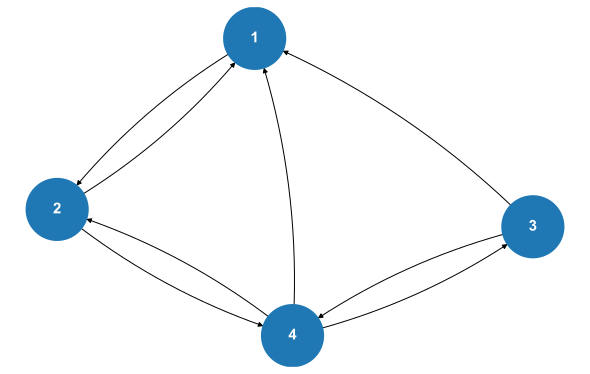

In [199]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
sns.set_context("poster")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

A = np.array([[0, 1 / 2, 1 / 2, 1 / 3],
              [1, 0, 0, 1 / 3],
              [0, 0, 0, 1 / 3],
              [0, 1 / 2, 1 / 2, 0]])

def plot_from_adjacency(adjacency_matrix, node_sizes=0.25):
    np.random.seed(25)
    plt.figure(figsize=(8, 5))
    G = nx.from_numpy_array(adjacency_matrix.T, create_using=nx.DiGraph)
    layout = nx.spring_layout(G)
    labels_dict={i: i+1 for i in range(adjacency_matrix.shape[0])}
    nx.draw(G, layout, 
            node_size=15000 * node_sizes, labels=labels_dict, with_labels=True, font_color='white', font_weight='bold', font_size=15, 
            connectionstyle='arc3, rad = 0.1')
    plt.show()

plot_from_adjacency(A)

From the research paper linked above:

> PageRank or PR(A) can be calculated using a simple iterative algorithm, and corresponds to the principal eigenvector of the normalized link matrix of the web.

We'll make sense of the algorithm in Homework 10: just know that this is where we're heading.

---

## Introduction

Before we get started, keep in mind that everything we're about to introduce only applies to square matrices. This was also true when we first studied invertibility, and for the same reason: we should think of eigenvalues and eigenvectors as properties of a linear transformation from $\mathbb{R}^n$ to $\mathbb{R}^n$ (that is, from a vector space to itself), not between vector spaces of different dimensions. Rectangular matrices will have their moment in [Chapter 10.1](../10_singular_value_decomposition/01-computing-svd.ipynb).

:::{note} Definition: Eigenvalues and Eigenvectors

Suppose $A$ is an $n \times n$ matrix. A **non-zero** vector $\vec v \in \mathbb{R}^n$ is an **eigenvector** of $A$ if:

$$A \vec v = \lambda \vec v$$

for some scalar $\lambda \in \mathbb{R}$. The scalar $\mathbf{\lambda}$ is called the **eigenvalue** of $A$ corresponding to $\vec v$.
:::

This definition is a bit hard to parse when you first look at it. But here's the intuitive interpretation.

:::{attention} If $\vec v$ is an eigenvector of $A$, then $A \vec v$ is a **vector that points in the same direction** as $\vec v$, just stretched by a factor of $\mathbf{\lambda}$!

As we've seen, the function $f(\vec v) = A \vec v$ is a **linear transformation** that maps vectors in $\mathbb{R}^n$ to vectors in $\mathbb{R}^n$. Eigenvectors of $A$ are vectors whose **directions are unchanged** by the linear transformation $f$. The corresponding eigenvalues are the scalars by which the eigenvectors are scaled.
:::


"Eigen" is a German word meaning "own", as in "one's own". So, an eigenvector is a vector who still points in its own direction when transformed by $A$.

### A First Example

Let's start with a $2 \times 2$ matrix:

$$A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$$

I've chosen the numbers in $A$ to be small enough that we can roughly eyeball the eigenvectors. Here's how I look at $A$:
- First, notice that both rows of $A$ sum to 3, meaning that
    $$\begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 3 \\ 3 \end{bmatrix} = 3 \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$
    This tells me that $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ is an eigenvector of $A$ with eigenvalue $3$. But, $\begin{bmatrix} 2 \\ 2 \end{bmatrix}$ is also an eigenvector of $A$ with the same eigenvalue, since

    $$\begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} \begin{bmatrix} 2 \\ 2 \end{bmatrix} = \begin{bmatrix} 6 \\ 6 \end{bmatrix} = 3 \begin{bmatrix} 2 \\ 2 \end{bmatrix}$$

    **Indeed, if $\vec v$ is an eigenvector of $A$ with eigenvalue $\mathbf{\lambda}$, then so is $c \vec v$ for any non-zero scalar $c$.** So really, eigenvectors define **directions**.

- Additionally, noticing that there'd be _some_ symmetry if I took the difference of the entries in each row of $A$, consider
    $$\begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} \begin{bmatrix} -1 \\ 1 \end{bmatrix} = \begin{bmatrix} 1 \\ -1 \end{bmatrix} = -1 \begin{bmatrix} -1 \\ 1 \end{bmatrix}$$
    This tells me that $\begin{bmatrix} -1 \\ 1 \end{bmatrix}$ is an eigenvector of $A$ with eigenvalue $-1$.

So, $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$ has two eigenvalues, $3$ and $-1$, and two corresponding eigenvectors, $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ 1 \end{bmatrix}$. In general, an $n \times n$ matrix has $n$ eigenvalues, but some of them may be the same, and some of them may not be real numbers. We'll see how to systematically find these eigenvalues and eigenvectors in just a bit.

Visually, this means that $\color{orange} \vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ lives on the same line as $\color{orange} A \vec v_1$, which is also the line that $\color{orange} c \vec v_1$ and $\color{orange} A(c \vec v_1)$ live on (for any non-zero scalar $c$). And, $\color{#3d81f6} \vec v_2 = \begin{bmatrix} -1 \\ 1 \end{bmatrix}$ lives on the same line as $\color{#3d81f6} A \vec v_2$.

But, if a vector isn't already on one of the two aforementioned lines – like $\color{#d81a60} \vec x = \begin{bmatrix} -1 \\ 0 \end{bmatrix}$ – then it will change directions when multiplied by $A$, and it is not an eigenvector.

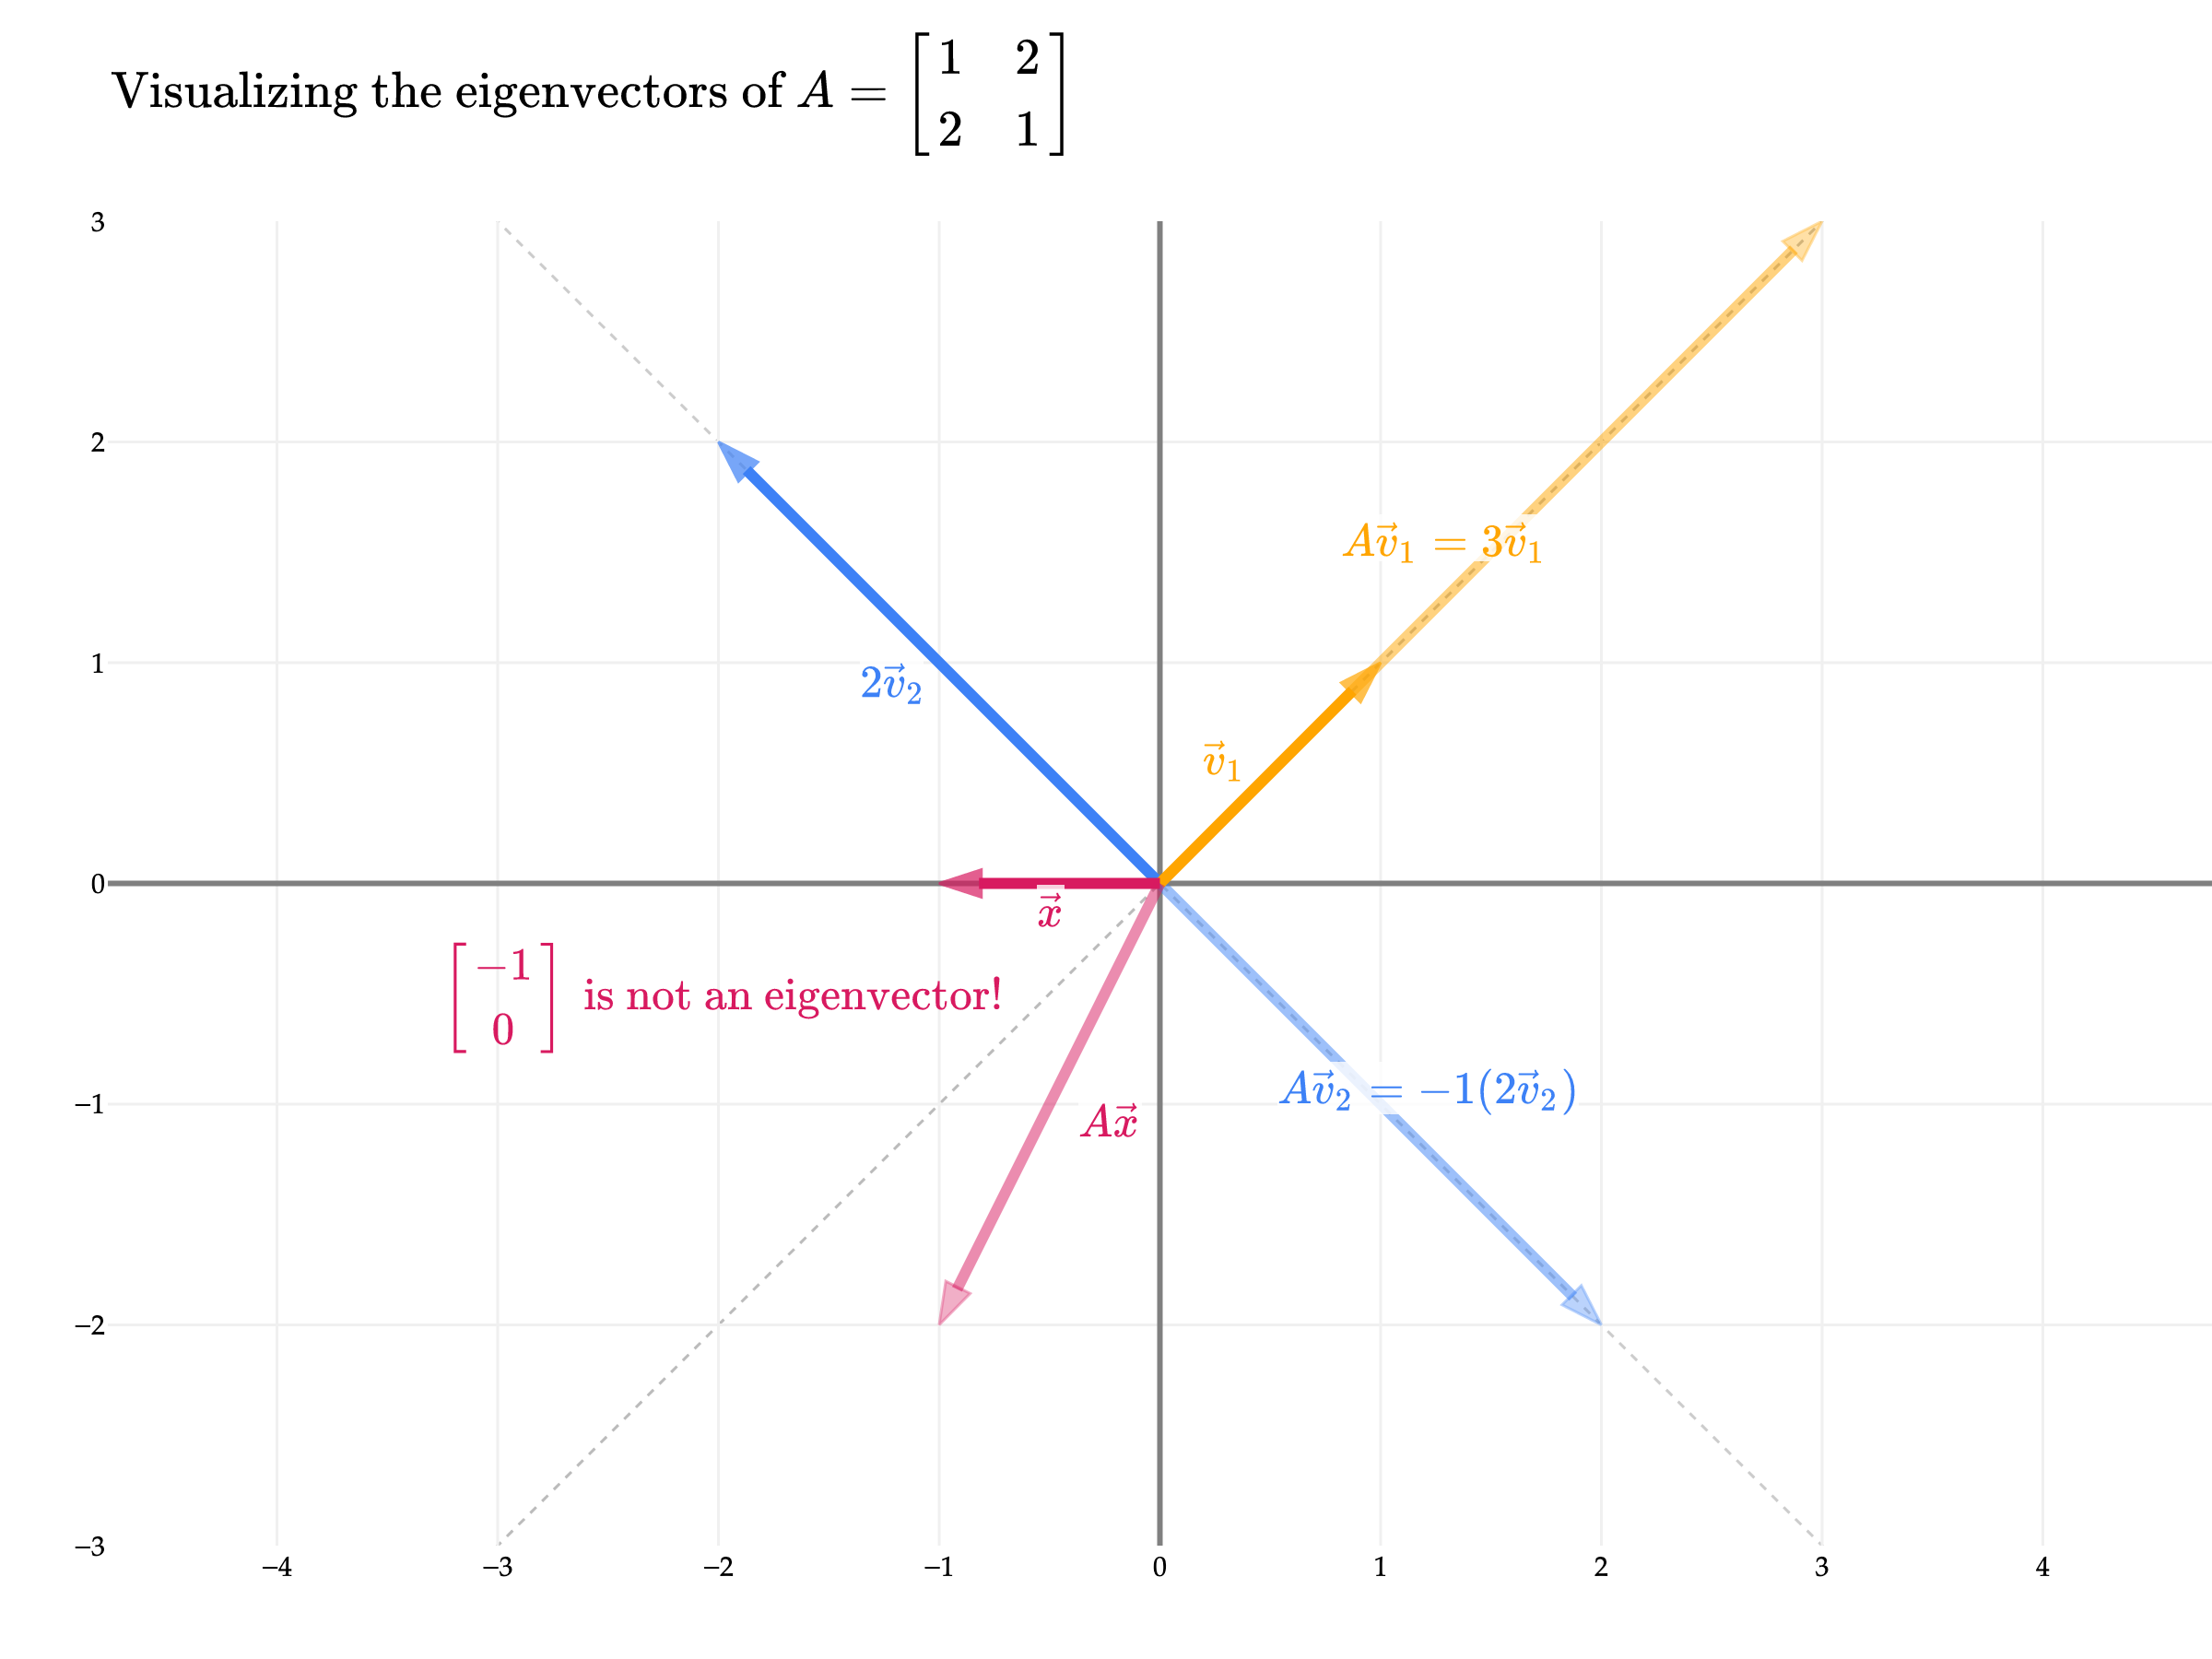

In [76]:
from utils import plot_vectors
import numpy as np

# Matrix
A = np.array([[1, 2], [2, 1]])

# Vectors
v1 = np.array([1, 1])      # eigenvector direction
v2 = np.array([-2, 2])    # same eigenvector direction, negative/scaled
x = -np.array([1, 0])
y = np.array([-2, -1])

Av1 = A @ v1
Av2 = A @ v2
Ax = A @ x
Ay = A @ y

# To set alpha=0.5 in hex, convert as follows:
# orange -> #FFA500   ===> with alpha=0.5: #80FFA500
# #3d81f6 -> with alpha=0.5: #803d81f6
# #d81a60 -> with alpha=0.5: #80d81a60
# #004d40 -> with alpha=0.5: #80004d40

vectors = [
    (tuple(v2), 'rgba(61,129,246,1.0)', r'$2\vec v_2$'),      # dimmed blue
    (tuple(Av2), 'rgba(61,129,246,0.5)', r'$A\vec v_2 = -1 (2\vec v_2)$'),    # full blue

    (tuple(v1), 'rgba(255,165,0,1.0)', r'$\vec v_1$'),       # dimmed orange
    (tuple(Av1), 'rgba(255,165,0,0.5)', r'$A\vec v_1 = 3 \vec v_1$'),     # full orange

    (tuple(x),  'rgba(216,26,96,1.0)', r'$\vec x$'),         # dimmed pink
    (tuple(Ax), 'rgba(216,26,96,0.5)', r'$A\vec x$'),        # full pink

]

# Prepare faint lines along the two eigenvector directions: [1,1] and [-1,1]
line_length = 6
eig1_dir = np.array([1, 1]) / np.linalg.norm([1, 1])
eig2_dir = np.array([-1, 1]) / np.linalg.norm([-1, 1])

eig1_line1 = eig1_dir * line_length
eig1_line2 = -eig1_dir * line_length
eig2_line1 = eig2_dir * line_length
eig2_line2 = -eig2_dir * line_length

background_lines = [
    ((eig1_line1[0], eig1_line1[1]), (eig1_line2[0], eig1_line2[1]), "#bbbbbb", "dot"),
    ((eig2_line1[0], eig2_line1[1]), (eig2_line2[0], eig2_line2[1]), "#cccccc", "dot"),
]

fig = plot_vectors(
    vectors,
    # background_lines=background_lines,
    vdeltay=0.1
)

# Add dotted lines in the eigenvector directions
for line in background_lines:
    (x0, y0), (x1, y1), color, dash = line
    fig.add_shape(
        type="line",
        x0=x0, y0=y0, x1=x1, y1=y1,
        line=dict(color=color, width=1, dash="dot"),
        layer="below"
    )

fig.update_layout(
    xaxis=dict(range=[-3, 3], dtick=1),
    yaxis=dict(scaleanchor="x", range=[-3, 3], dtick=1),
    title=r"$$\text{Visualizing the eigenvectors of } A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$$",
    margin=dict(l=0, r=0, t=80, b=0)
)

# Annotate [-1, 0] is not an eigenvector at the bottom left in #d81a60
fig.add_annotation(
    x=-2, y=-0.5,
    text=r"$$\begin{bmatrix} -1 \\ 0 \end{bmatrix} \text{ is not an eigenvector!}$$",
    font=dict(color="#d81a60", size=16),
    showarrow=False,
    align="left"
)

fig.show(scale=3, renderer='png')

Just to be 100% clear, I've used $\color{#3d81f6} 2 \vec v_2$ instead of $\color{#3d81f6} \vec v_2$ above just to illustrate the fact that eigenvectors are only defined up to a scalar multiple; $\color{#3d81f6} 2 \vec v_2$ is just as good as an eigenvector as $\color{#3d81f6} \vec v_2$ is, and both correspond to the same eigenvalue, $\mathbf{\lambda} = 1$.

You might notice that the two eigenvectors of $A$ corresponding to the two different eigenvalues are orthogonal in the example above. This is not true in general for any $2 \times 2$ matrix, but there's a specific reason it's true for $A$: it's **symmetric**. I'll elaborate more on this idea in [Chapter 9.5](05-symmetric-matrices-spectral-theorem.ipynb), but for now, just remember that symmetric matrices have orthogonal eigenvectors.

### Finding Eigenvalues using `numpy`

Just to show you another example, consider

$$B = \begin{bmatrix} 2 & 5 \\ 1 & 0 \end{bmatrix}$$

Its eigenvalues and eigenvectors aren't particularly nice, and since we don't yet have a way to find them by hand, now is as good as a time as any to use `numpy`:

In [94]:
B = np.array([[2, 5],
              [1, 0]])

np.linalg.eig(B)

EigResult(eigenvalues=array([ 3.44948974, -1.44948974]), eigenvectors=array([[ 0.96045535, -0.82311938],
       [ 0.27843404,  0.56786837]]))

So, $B$ has eigenvalues of $\approx 3.45$ and $\approx -1.45$. **Note that the eigenvectors are the columns of the matrix returned**, not the rows!

In [ ]:
eigvals, eigvecs = np.linalg.eig(B)
for i in range(eigvecs.shape[1]):
    print(f"Eigenvector {i+1}: {eigvecs[:, i]}")
    print(f"Eigenvalue {i+1}: {eigvals[i]}")
    print()

Eigenvector 1: [0.96045535 0.27843404]
Eigenvalue 1: 3.4494897427831783

Eigenvector 2: [-0.82311938  0.56786837]
Eigenvalue 2: -1.449489742783178



`eigvecs` is a matrix where each column is an eigenvector of $B$. For now, call this matrix $P$. Below, I calculate $P^TP$, which contains the dot products of all pairs of eigenvectors of $B$. The diagonal of this matrix contains the dot products of each eigenvector with itself; since these are 1, this tells us that the returned eigenvectors are unit vectors. This was a design decision by the implementors of `np.linalg.eig` – remember that we can scale an eigenvector by any non-zero scalar and it is still an eigenvector. The off-diagonal entries of -0.632 tell us that the two eigenvectors are not orthogonal.

In [100]:
eigvecs.T @ eigvecs

array([[ 1.        , -0.63245553],
       [-0.63245553,  1.        ]])

Let's take a look at the directions of the eigenvectors for $B$.

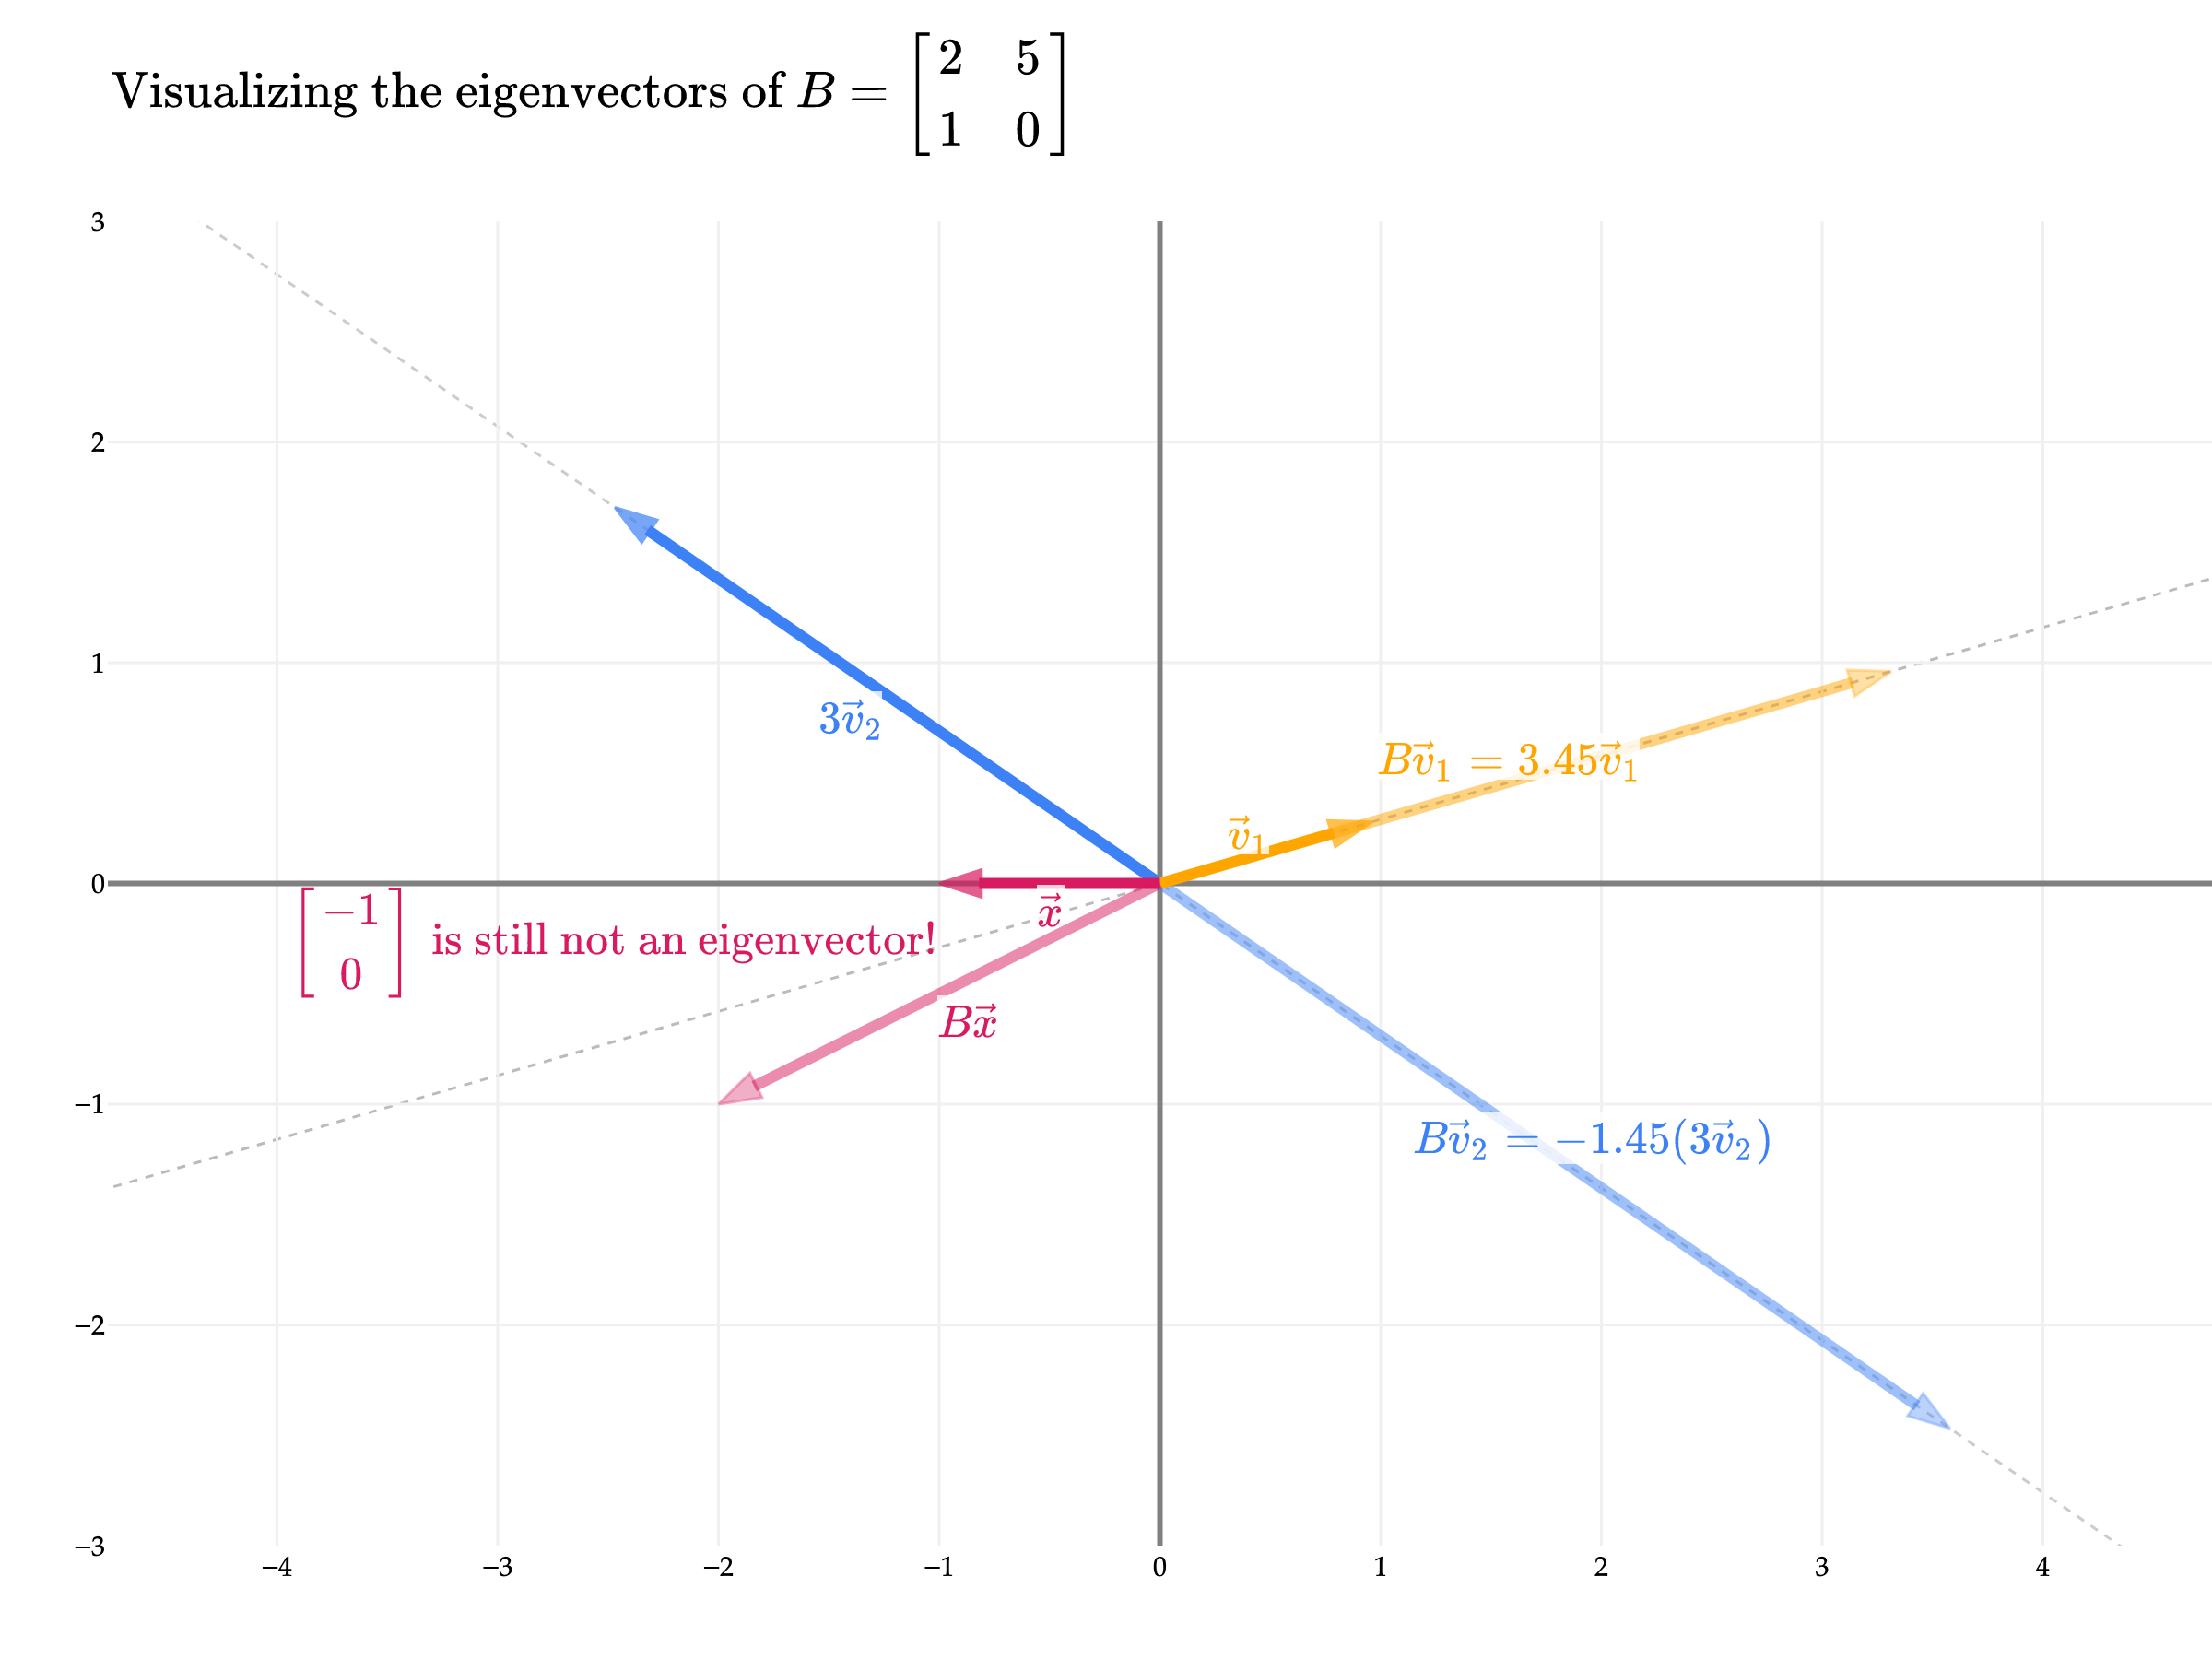

In [1]:
from utils import plot_vectors
import numpy as np

# Matrix
A = np.array([[2, 5], [1, 0]])

# Find eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Pick v1 to be the *unit* eigenvector for the first eigenvalue (use eigvecs[:,0])
v1_unit = eigvecs[:, 0]# / np.linalg.norm(eigvecs[:, 0])
v1 = v1_unit

# Pick v2 to be *three times* the unit eigenvector for the second eigenvalue (eigvecs[:,1])
v2 = 3 * eigvecs[:, 1]# / np.linalg.norm(eigvecs[:, 1])

x = -np.array([1, 0])

Av1 = A @ v1
Av2 = A @ v2
Ax = A @ x

# To set alpha=0.5 in hex, convert as follows:
# orange -> #FFA500   ===> with alpha=0.5: #80FFA500
# #3d81f6 -> with alpha=0.5: #803d81f6
# #d81a60 -> with alpha=0.5: #80d81a60
# #004d40 -> with alpha=0.5: #80004d40

vectors = [
    (tuple(v2), 'rgba(61,129,246,1.0)', r'$3\vec v_2$'),      # dimmed blue (same as A example but 3*v2)
    (tuple(Av2), 'rgba(61,129,246,0.5)', r'$B\vec v_2 = %.2f (3\vec v_2)$' % eigvals[1]),    # full blue, faded
    (tuple(v1), 'rgba(255,165,0,1.0)', r'$\vec v_1$'),       # dimmed orange (matches prior coloring)
    (tuple(Av1), 'rgba(255,165,0,0.5)', r'$B\vec v_1 = %.2f \vec v_1$' % eigvals[0]),     # full orange, faded
    (tuple(x),  'rgba(216,26,96,1.0)', r'$\vec x$'),         # dimmed pink
    (tuple(Ax), 'rgba(216,26,96,0.5)', r'$B\vec x$'),        # full pink, faded
]

# Prepare faint lines along the two eigenvector directions (use actual directions from eigvecs)
line_length = 6
eig1_dir = v1_unit
eig2_dir = eigvecs[:, 1] / np.linalg.norm(eigvecs[:, 1])

eig1_line1 = eig1_dir * line_length
eig1_line2 = -eig1_dir * line_length
eig2_line1 = eig2_dir * line_length
eig2_line2 = -eig2_dir * line_length

background_lines = [
    ((eig1_line1[0], eig1_line1[1]), (eig1_line2[0], eig1_line2[1]), "#bbbbbb", "dot"),
    ((eig2_line1[0], eig2_line1[1]), (eig2_line2[0], eig2_line2[1]), "#cccccc", "dot"),
]

fig = plot_vectors(
    vectors,
    # background_lines=background_lines,
    vdeltay=0.1
)

# Add dotted lines in the eigenvector directions
for line in background_lines:
    (x0, y0), (x1, y1), color, dash = line
    fig.add_shape(
        type="line",
        x0=x0, y0=y0, x1=x1, y1=y1,
        line=dict(color=color, width=1, dash="dot"),
        layer="below"
    )

fig.update_layout(
    xaxis=dict(range=[-3, 3], dtick=1),
    yaxis=dict(scaleanchor="x", range=[-3, 3], dtick=1),
    title=r"$$\text{Visualizing the eigenvectors of } B = \begin{bmatrix} 2 & 5 \\ 1 & 0 \end{bmatrix}$$",
    margin=dict(l=0, r=0, t=80, b=0)
# 
)

# Annotate [-1, 0] is not an eigenvector at the bottom left in #d81a60
fig.add_annotation(
    x=-2.5, y=-0.25,
    text=r"$$\begin{bmatrix} -1 \\ 0 \end{bmatrix} \text{ is still not an eigenvector!}$$",
    font=dict(color="#d81a60", size=16),
    showarrow=False,
    align="left"
)

fig.show(scale=3, renderer='png')

While the eigenvectors of $B$ are not orthogonal, they are still linearly independent and span all of $\mathbb{R}^2$. This was also the case in the $A$ example above. **The fact that the eigenvectors of an $n \times n$ matrix are linearly independent and span all of $\mathbb{R}^n$ is also not guaranteed to be true, though it's a desirable property.** The class of matrices that have this property are called **diagonalizable**, which are the focus of [Chapter 9.4](04-multiplicities-diagonalization.ipynb).

Let's consider a few more examples, each of which is meant to highlight a different key property of eigenvalues and eigenvectors.

### Example: Matrix Powers

Let $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$ be the matrix from the first example above. What are the eigenvalues and eigenvectors of $A^2$? Find them manually. You should notice the property below.

:::{seealso} Solution
:class: dropdown

$$\begin{align*}
A^2 &= \begin{bmatrix} 1 & 2 \\ 2 & 1\end{bmatrix}\begin{bmatrix} 1 & 2 \\ 2 & 1\end{bmatrix}
\\&= \begin{bmatrix} 5 & 4 \\ 4 & 5 \end{bmatrix}
\end{align*}$$

Similar to the original example, $A^2$'s rows both sum to the same number, 9, meaning that 
$$\begin{bmatrix} 5 & 4 \\ 4 & 5 \end{bmatrix}\begin{bmatrix}1 \\ 1\end{bmatrix} = \begin{bmatrix}9 \\ 9\end{bmatrix} = 9\begin{bmatrix}1 \\ 1\end{bmatrix}$$

We can do the same thing with $A^2 \begin{bmatrix}1 \\ -1\end{bmatrix}$:
$$A^2 \begin{bmatrix}1 \\ -1\end{bmatrix} = \begin{bmatrix}1 \\ -1\end{bmatrix}= 1\begin{bmatrix}1 \\ -1\end{bmatrix}$$

So the eigenvalues of $A^2$ are $9$ and $1$, and their respective eigenvectors are $\begin{bmatrix}1 \\ 1\end{bmatrix}$ and $\begin{bmatrix}1 \\ -1\end{bmatrix}$.

But, these are the same two eigenvectors that $A$ has, and the corresponding eigenvalues are the squares of $A$'s eigenvalues, since $3^2 = 9$ and $(-1)^2 = 1$. Is this true more generally? **Yes!**

:::

:::{attention} If $\mathbf{\lambda}$ is an eigenvalue of $A$ with eigenvector $\vec v$, then $\mathbf{\lambda}^k$ is an eigenvalue of $A^k$ with **the same** eigenvector $\vec v$. (Click to see the proof.)
:class: dropdown
A quick proof: suppose $A \vec v = \lambda \vec v$. Then, $$A^2 \vec v = A (A \vec v) = A (\lambda \vec v) = \lambda (A \vec v) = \lambda^2 \vec v$$ This logic can be extended to $A^3$, then $A^4$, and so on. (If you are familiar with induction from EECS 203, you can think of this as an inductive proof.)

Note that the converse of this statement is not necessarily true, meaning it's possible for $A^2$ to have an eigenvector that is not an eigenvector of $A$. For example, if $A$ corresponds to a rotation by 90º degrees (or $\frac{\pi}{2}$ radians), then $A^2$ corresponds to a rotation by 180º degrees (or $\pi$ radians). No vector lies on the same line after rotation by 90º degrees, but all vectors lie on the same line after rotation by 180º degrees. So, in this example, $A^2$ has plenty of eigenvectors that $A$ does not have.
:::


### Example: Non-Invertible Matrices

Let $A = \begin{bmatrix} 1 & 4 \\ 3 & 12 \end{bmatrix}$. Notice that $\text{rank}(A) = 1$. $A$ has an eigenvalue of $13$ with eigenvector $\begin{bmatrix} 1 \\ 3 \end{bmatrix}$ – verify that this is the case. Does it have another eigenvalue? What is the corresponding eigenvector?

:::{seealso} Solution
:class: dropdown

Since $\text{rank}(A) = 1$, $A$ has a non-trivial null space, and any vector in the null space will get sent to $0$ times itself when multiplied by $A$. Since $4 \cdot \text{column 1} = \text{column 2}$, the null space of $A$ is spanned by the vector $\begin{bmatrix} 4 \\ -1 \end{bmatrix}$. So,

$$A \begin{bmatrix} 4 \\ -1 \end{bmatrix} = \begin{bmatrix} 1 & 4 \\ 3 & 12 \end{bmatrix} \begin{bmatrix} 4 \\ -1 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} = 0 \begin{bmatrix} 4 \\ -3 \end{bmatrix}$$

$\vec 0$ can't be an eigenvector, but $0$ is a perfectly good eigenvalue.

Our intuition tells us that $A$ should have another eigenvalue, since it's a $2 \times 2$ matrix. It happens to be 13, corresponding to the eigenvector $\begin{bmatrix} 1 \\ 3 \end{bmatrix}$. In [Chapter 9.2: The Characteristic Polynomial](02-characteristic-polynomial.ipynb), we'll see how to find this eigenvalue-eigenvector pair without guesswork.

:::

:::{attention} $0$ is an eigenvalue of $A$ if and only if $A$ is not invertible. (Click to see more details.)
:class: dropdown
If $A$ is invertible, then the only solution to $A \vec v = 0 \vec v = \vec 0$ is the trivial solution where $\vec v$ is the zero vector itself. But, we defined eigenvectors to be non-zero vectors. So, 0 can't be an eigenvalue of an invertible matrix. If $A$ is not invertible, then $A$ has a non-trivial null space, and any non-zero vector in the null space is an eigenvector corresponding to the eigenvalue 0.
:::

### Example: The Identity Matrix

What are the eigenvalues and eigenvectors of $I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$?

:::{seealso} Solution
:class: dropdown

The identity matrix multiplied by any vector $\vec v$ returns that same vector back, meaning that all vectors in $\mathbb{R}^2$ are eigenvectors of $I$, all with eigenvalue $1$.

This is the first example we've seen so far where there exist multiple "lines" or "directions" of eigenvectors for a single eigenvalue. The vectors $\begin{bmatrix} 2 \\ 3 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ 4 \end{bmatrix}$ are both eigenvectors of $I$ with eigenvalue $1$ but they don't lie on the same line. We will study this idea – of having multiple eigenvector directions for a single eigenvalue – more precisely in [Chapter 9.4](04-multiplicities-diagonalization.ipynb).
:::

A question on your mind might be, how do we find the eigenvalues of a generic matrix, when they aren't easy to eyeball? Keep reading! The bottom of [Chapter 9.2](./02-characteristic-polynomial.ipynb) also has a great summary of the key ideas from this section.